Link de colab:
https://colab.research.google.com/drive/1gTg60n6lCrDq8WHkokd8CAFJy7LY-NMP?usp=sharing

In [1]:
!pip install -q kagglehub scikit-learn

In [2]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report

In [3]:
print("Versión de TensorFlow: " + str(tf.__version__))

lista_gpus = tf.config.list_physical_devices("GPU")
print("GPUs detectadas: " + str(lista_gpus))

Versión de TensorFlow: 2.19.0
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
ruta_dataset = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Ruta donde se descargó el dataset: " + str(ruta_dataset))
print("Contenido inicial:")
print(os.listdir(ruta_dataset))

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Ruta donde se descargó el dataset: /kaggle/input/chest-xray-pneumonia
Contenido inicial:
['chest_xray']


In [5]:
ruta_principal = os.path.join(ruta_dataset, "chest_xray")

print("Ruta principal de imágenes: " + str(ruta_principal))
print("Contenido de chest_xray:")
print(os.listdir(ruta_principal))

Ruta principal de imágenes: /kaggle/input/chest-xray-pneumonia/chest_xray
Contenido de chest_xray:
['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [6]:
lista_rutas = []
lista_etiquetas = []

lista_carpetas = ["train", "val", "test"]
lista_clases = ["NORMAL", "PNEUMONIA"]

indice_carpeta = 0
while indice_carpeta < len(lista_carpetas):
    nombre_carpeta = lista_carpetas[indice_carpeta]
    ruta_carpeta = os.path.join(ruta_principal, nombre_carpeta)

    indice_clase = 0
    while indice_clase < len(lista_clases):
        nombre_clase = lista_clases[indice_clase]
        ruta_clase = os.path.join(ruta_carpeta, nombre_clase)

        if os.path.exists(ruta_clase):
            archivos_clase = os.listdir(ruta_clase)

            indice_archivo = 0
            while indice_archivo < len(archivos_clase):
                nombre_archivo = archivos_clase[indice_archivo]
                ruta_imagen = os.path.join(ruta_clase, nombre_archivo)

                lista_rutas.append(ruta_imagen)

                if nombre_clase == "NORMAL":
                    lista_etiquetas.append(0)
                else:
                    lista_etiquetas.append(1)

                indice_archivo = indice_archivo + 1

        indice_clase = indice_clase + 1

    indice_carpeta = indice_carpeta + 1

tabla_total = pd.DataFrame()
tabla_total["ruta"] = lista_rutas
tabla_total["etiqueta"] = lista_etiquetas

print("Cantidad total de imágenes: " + str(len(tabla_total)))
print("Conteo por clase:")
print(tabla_total["etiqueta"].value_counts())

Cantidad total de imágenes: 5856
Conteo por clase:
etiqueta
1    4273
0    1583
Name: count, dtype: int64


In [7]:
rutas_totales = tabla_total["ruta"]
etiquetas_totales = tabla_total["etiqueta"]

rutas_entrenamiento, rutas_temporales, etiquetas_entrenamiento, etiquetas_temporales = train_test_split(
    rutas_totales,
    etiquetas_totales,
    test_size=0.30,
    random_state=42,
    stratify=etiquetas_totales
)

rutas_validacion, rutas_prueba, etiquetas_validacion, etiquetas_prueba = train_test_split(
    rutas_temporales,
    etiquetas_temporales,
    test_size=0.50,
    random_state=42,
    stratify=etiquetas_temporales
)

tabla_entrenamiento = pd.DataFrame()
tabla_entrenamiento["ruta"] = rutas_entrenamiento
tabla_entrenamiento["etiqueta"] = etiquetas_entrenamiento

tabla_validacion = pd.DataFrame()
tabla_validacion["ruta"] = rutas_validacion
tabla_validacion["etiqueta"] = etiquetas_validacion

tabla_prueba = pd.DataFrame()
tabla_prueba["ruta"] = rutas_prueba
tabla_prueba["etiqueta"] = etiquetas_prueba

print("Cantidad entrenamiento: " + str(len(tabla_entrenamiento)))
print("Cantidad validación: " + str(len(tabla_validacion)))
print("Cantidad prueba: " + str(len(tabla_prueba)))

Cantidad entrenamiento: 4099
Cantidad validación: 878
Cantidad prueba: 879


In [8]:
rutas_totales = tabla_total["ruta"]
etiquetas_totales = tabla_total["etiqueta"]

rutas_entrenamiento, rutas_temporales, etiquetas_entrenamiento, etiquetas_temporales = train_test_split(
    rutas_totales,
    etiquetas_totales,
    test_size=0.30,
    random_state=42,
    stratify=etiquetas_totales
)

rutas_validacion, rutas_prueba, etiquetas_validacion, etiquetas_prueba = train_test_split(
    rutas_temporales,
    etiquetas_temporales,
    test_size=0.50,
    random_state=42,
    stratify=etiquetas_temporales
)

tabla_entrenamiento = pd.DataFrame()
tabla_entrenamiento["ruta"] = rutas_entrenamiento
tabla_entrenamiento["etiqueta"] = etiquetas_entrenamiento

tabla_validacion = pd.DataFrame()
tabla_validacion["ruta"] = rutas_validacion
tabla_validacion["etiqueta"] = etiquetas_validacion

tabla_prueba = pd.DataFrame()
tabla_prueba["ruta"] = rutas_prueba
tabla_prueba["etiqueta"] = etiquetas_prueba

print("Cantidad entrenamiento: " + str(len(tabla_entrenamiento)))
print("Cantidad validación: " + str(len(tabla_validacion)))
print("Cantidad prueba: " + str(len(tabla_prueba)))

Cantidad entrenamiento: 4099
Cantidad validación: 878
Cantidad prueba: 879


In [9]:
print("Distribución de clases en entrenamiento:")
print(tabla_entrenamiento["etiqueta"].value_counts(normalize=True))
print("")

print("Distribución de clases en validación:")
print(tabla_validacion["etiqueta"].value_counts(normalize=True))
print("")

print("Distribución de clases en prueba:")
print(tabla_prueba["etiqueta"].value_counts(normalize=True))

Distribución de clases en entrenamiento:
etiqueta
1    0.72969
0    0.27031
Name: proportion, dtype: float64

Distribución de clases en validación:
etiqueta
1    0.730068
0    0.269932
Name: proportion, dtype: float64

Distribución de clases en prueba:
etiqueta
1    0.729238
0    0.270762
Name: proportion, dtype: float64


In [10]:
def convertir_etiqueta_a_texto(valor):
    if valor == 0:
        return "NORMAL"
    else:
        return "PNEUMONIA"

tabla_entrenamiento["clase"] = tabla_entrenamiento["etiqueta"].apply(convertir_etiqueta_a_texto)
tabla_validacion["clase"] = tabla_validacion["etiqueta"].apply(convertir_etiqueta_a_texto)
tabla_prueba["clase"] = tabla_prueba["etiqueta"].apply(convertir_etiqueta_a_texto)

print(tabla_entrenamiento.head())

                                                   ruta  etiqueta      clase
5690  /kaggle/input/chest-xray-pneumonia/chest_xray/...         1  PNEUMONIA
2638  /kaggle/input/chest-xray-pneumonia/chest_xray/...         1  PNEUMONIA
4711  /kaggle/input/chest-xray-pneumonia/chest_xray/...         1  PNEUMONIA
3253  /kaggle/input/chest-xray-pneumonia/chest_xray/...         1  PNEUMONIA
777   /kaggle/input/chest-xray-pneumonia/chest_xray/...         0     NORMAL


In [11]:
tamano_imagen = 224
tamano_lote = 32
numero_epocas = 10
tasa_aprendizaje = 0.001

print("Tamaño imagen: " + str(tamano_imagen))
print("Tamaño lote: " + str(tamano_lote))
print("Número de épocas: " + str(numero_epocas))
print("Tasa de aprendizaje: " + str(tasa_aprendizaje))

Tamaño imagen: 224
Tamaño lote: 32
Número de épocas: 10
Tasa de aprendizaje: 0.001


In [12]:
generador_entrenamiento = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=8,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05
)

generador_validacion_prueba = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0
)

print("Generadores creados correctamente")

Generadores creados correctamente


In [13]:
flujo_entrenamiento = generador_entrenamiento.flow_from_dataframe(
    dataframe=tabla_entrenamiento,
    x_col="ruta",
    y_col="clase",
    target_size=(tamano_imagen, tamano_imagen),
    batch_size=tamano_lote,
    class_mode="binary",
    shuffle=True
)

flujo_validacion = generador_validacion_prueba.flow_from_dataframe(
    dataframe=tabla_validacion,
    x_col="ruta",
    y_col="clase",
    target_size=(tamano_imagen, tamano_imagen),
    batch_size=tamano_lote,
    class_mode="binary",
    shuffle=False
)

flujo_prueba = generador_validacion_prueba.flow_from_dataframe(
    dataframe=tabla_prueba,
    x_col="ruta",
    y_col="clase",
    target_size=(tamano_imagen, tamano_imagen),
    batch_size=tamano_lote,
    class_mode="binary",
    shuffle=False
)

Found 4099 validated image filenames belonging to 2 classes.
Found 878 validated image filenames belonging to 2 classes.
Found 879 validated image filenames belonging to 2 classes.


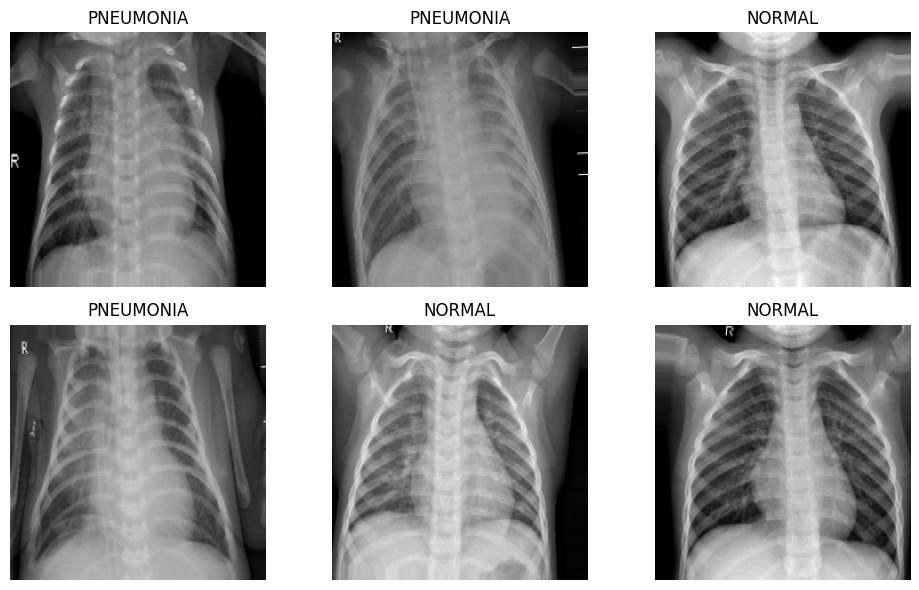

In [14]:
imagenes_lote, etiquetas_lote = next(flujo_entrenamiento)

plt.figure(figsize=(10, 6))

indice = 0
while indice < 6:
    plt.subplot(2, 3, indice + 1)
    plt.imshow(imagenes_lote[indice])

    if etiquetas_lote[indice] == 0:
        titulo_imagen = "NORMAL"
    else:
        titulo_imagen = "PNEUMONIA"

    plt.title(titulo_imagen)
    plt.axis("off")
    indice = indice + 1

plt.tight_layout()
plt.show()

In [15]:
def crear_modelo_preentrenado(nombre_modelo):
    entrada_modelo = tf.keras.Input(shape=(tamano_imagen, tamano_imagen, 3))

    modelo_base = None

    if nombre_modelo == "MobileNetV2":
        modelo_base = tf.keras.applications.MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_tensor=entrada_modelo
        )
    else:
        if nombre_modelo == "DenseNet121":
            modelo_base = tf.keras.applications.DenseNet121(
                weights="imagenet",
                include_top=False,
                input_tensor=entrada_modelo
            )

    modelo_base.trainable = False

    salida_temporal = modelo_base.output
    salida_temporal = tf.keras.layers.GlobalAveragePooling2D()(salida_temporal)
    salida_temporal = tf.keras.layers.Dropout(0.30)(salida_temporal)
    salida_final = tf.keras.layers.Dense(1, activation="sigmoid")(salida_temporal)

    modelo_completo = tf.keras.Model(inputs=entrada_modelo, outputs=salida_final)

    return modelo_completo, modelo_base

In [16]:
modelo_mobilenet, base_mobilenet = crear_modelo_preentrenado("MobileNetV2")
modelo_densenet, base_densenet = crear_modelo_preentrenado("DenseNet121")

print("Modelos creados correctamente")

/tmp/ipykernel_3556/189334273.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  modelo_base = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Modelos creados correctamente


In [17]:
print("Capas entrenables en la base MobileNetV2: " + str(base_mobilenet.trainable))
print("Capas entrenables en la base DenseNet121: " + str(base_densenet.trainable))

Capas entrenables en la base MobileNetV2: False
Capas entrenables en la base DenseNet121: False


In [18]:
optimizador_mobilenet = tf.keras.optimizers.Adam(learning_rate=tasa_aprendizaje)
optimizador_densenet = tf.keras.optimizers.Adam(learning_rate=tasa_aprendizaje)

modelo_mobilenet.compile(
    optimizer=optimizador_mobilenet,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

modelo_densenet.compile(
    optimizer=optimizador_densenet,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Modelos compilados correctamente")

Modelos compilados correctamente


In [19]:
detener_temprano = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("Early Stopping configurado")

Early Stopping configurado


In [20]:
inicio_entrenamiento_mobilenet = time.time()

historial_mobilenet = modelo_mobilenet.fit(
    flujo_entrenamiento,
    validation_data=flujo_validacion,
    epochs=numero_epocas,
    callbacks=[detener_temprano]
)

fin_entrenamiento_mobilenet = time.time()

tiempo_entrenamiento_mobilenet = fin_entrenamiento_mobilenet - inicio_entrenamiento_mobilenet

print("Tiempo de entrenamiento MobileNetV2: " + str(tiempo_entrenamiento_mobilenet) + " segundos")

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.8685 - loss: 0.3006 - val_accuracy: 0.9226 - val_loss: 0.2016
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 89s 694ms/step - accuracy: 0.9241 - loss: 0.1910 - val_accuracy: 0.9328 - val_loss: 0.1653
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 89s 691ms/step - accuracy: 0.9297 - loss: 0.1766 - val_accuracy: 0.9499 - val_loss: 0.1428
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 89s 694ms/step - accuracy: 0.9432 - loss: 0.1529 - val_accuracy: 0.9294 - val_loss: 0.1668
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 89s 688ms/step - accuracy: 0.9395 - loss: 0.1548 - val_accuracy: 0.9419 - val_loss: 0.1467
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 88s 681ms/step - accuracy: 0.9412 - loss: 0.1462 - val_accuracy: 0.9351 - val_loss: 0.1463
Tiempo de entrenamiento MobileNetV2: 602.9309709072113 segundos


In [21]:
inicio_entrenamiento_densenet = time.time()

historial_densenet = modelo_densenet.fit(
    flujo_entrenamiento,
    validation_data=flujo_validacion,
    epochs=numero_epocas,
    callbacks=[detener_temprano]
)

fin_entrenamiento_densenet = time.time()

tiempo_entrenamiento_densenet = fin_entrenamiento_densenet - inicio_entrenamiento_densenet

print("Tiempo de entrenamiento DenseNet121: " + str(tiempo_entrenamiento_densenet) + " segundos")

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 157s 1000ms/step - accuracy: 0.7963 - loss: 0.4423 - val_accuracy: 0.9112 - val_loss: 0.2675
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 91s 703ms/step - accuracy: 0.8892 - loss: 0.2678 - val_accuracy: 0.9226 - val_loss: 0.2183
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 90s 701ms/step - accuracy: 0.9053 - loss: 0.2342 - val_accuracy: 0.9294 - val_loss: 0.1993
Tiempo de entrenamiento DenseNet121: 340.00407814979553 segundos


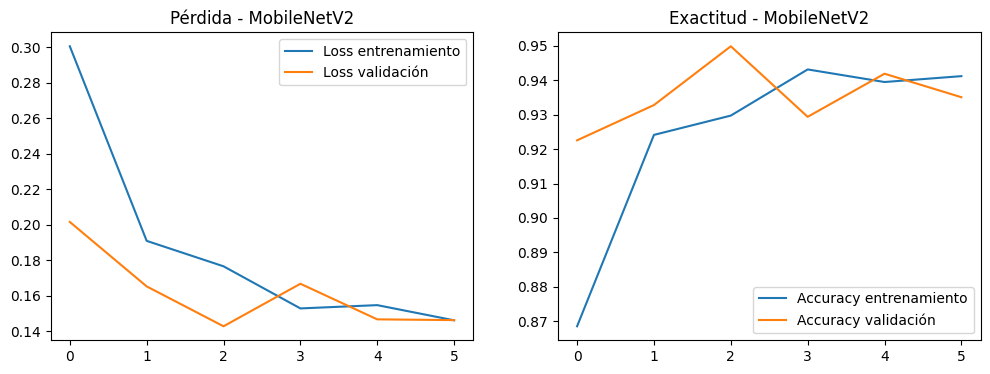

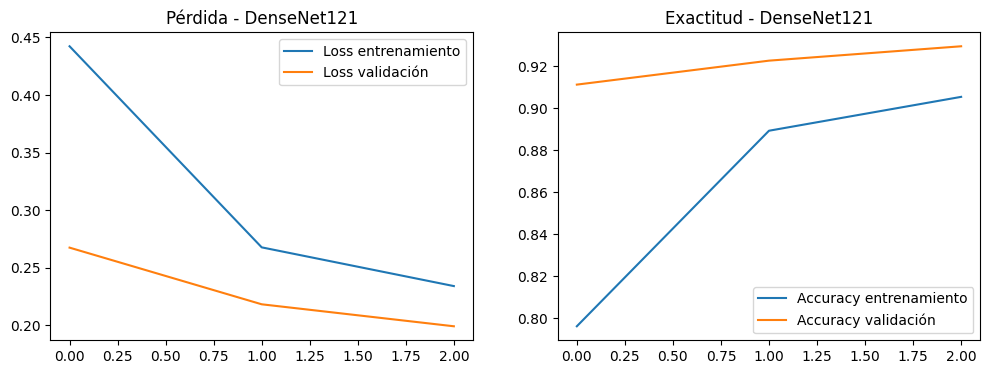

In [22]:
def graficar_historial(historial, nombre_modelo):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(historial.history["loss"], label="Loss entrenamiento")
    plt.plot(historial.history["val_loss"], label="Loss validación")
    plt.title("Pérdida - " + str(nombre_modelo))
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(historial.history["accuracy"], label="Accuracy entrenamiento")
    plt.plot(historial.history["val_accuracy"], label="Accuracy validación")
    plt.title("Exactitud - " + str(nombre_modelo))
    plt.legend()

    plt.show()

graficar_historial(historial_mobilenet, "MobileNetV2")
graficar_historial(historial_densenet, "DenseNet121")

In [23]:
def evaluar_modelo(modelo, flujo_datos, nombre_modelo):
    probabilidades = modelo.predict(flujo_datos)
    lista_predicciones = []

    indice = 0
    while indice < len(probabilidades):
        valor_probabilidad = probabilidades[indice][0]

        if valor_probabilidad >= 0.5:
            lista_predicciones.append(1)
        else:
            lista_predicciones.append(0)

        indice = indice + 1

    etiquetas_reales = flujo_datos.classes

    metrica_accuracy = accuracy_score(etiquetas_reales, lista_predicciones)
    metrica_f1 = f1_score(etiquetas_reales, lista_predicciones, pos_label=1)
    metrica_recall = recall_score(etiquetas_reales, lista_predicciones, pos_label=1)

    print("Resultados de: " + str(nombre_modelo))
    print("Accuracy: " + str(metrica_accuracy))
    print("F1-score Neumonía: " + str(metrica_f1))
    print("Recall Neumonía: " + str(metrica_recall))
    print("")
    print("Reporte de clasificación:")
    print(classification_report(etiquetas_reales, lista_predicciones, target_names=["NORMAL", "PNEUMONIA"]))

    return metrica_accuracy, metrica_f1, metrica_recall, lista_predicciones, etiquetas_reales

In [24]:
accuracy_mobilenet, f1_mobilenet, recall_mobilenet, predicciones_mobilenet, reales_mobilenet = evaluar_modelo(
    modelo_mobilenet,
    flujo_prueba,
    "MobileNetV2"
)

accuracy_densenet, f1_densenet, recall_densenet, predicciones_densenet, reales_densenet = evaluar_modelo(
    modelo_densenet,
    flujo_prueba,
    "DenseNet121"
)

28/28 ━━━━━━━━━━━━━━━━━━━━ 29s 877ms/step
Resultados de: MobileNetV2
Accuracy: 0.9488054607508533
F1-score Neumonía: 0.9648711943793911
Recall Neumonía: 0.9641185647425897

Reporte de clasificación:
              precision    recall  f1-score   support

      NORMAL       0.90      0.91      0.91       238
   PNEUMONIA       0.97      0.96      0.96       641

    accuracy                           0.95       879
   macro avg       0.93      0.94      0.94       879
weighted avg       0.95      0.95      0.95       879

28/28 ━━━━━━━━━━━━━━━━━━━━ 36s 886ms/step
Resultados de: DenseNet121
Accuracy: 0.8953356086461889
F1-score Neumonía: 0.9289026275115919
Recall Neumonía: 0.9375975039001561

Reporte de clasificación:
              precision    recall  f1-score   support

      NORMAL       0.82      0.78      0.80       238
   PNEUMONIA       0.92      0.94      0.93       641

    accuracy                           0.90       879
   macro avg       0.87      0.86      0.87       879
wei

In [25]:
ruta_guardado_mobilenet = "/content/modelo_mobilenet.h5"
ruta_guardado_densenet = "/content/modelo_densenet.h5"

modelo_mobilenet.save(ruta_guardado_mobilenet)
modelo_densenet.save(ruta_guardado_densenet)

tamano_bytes_mobilenet = os.path.getsize(ruta_guardado_mobilenet)
tamano_bytes_densenet = os.path.getsize(ruta_guardado_densenet)

tamano_mb_mobilenet = tamano_bytes_mobilenet / (1024 * 1024)
tamano_mb_densenet = tamano_bytes_densenet / (1024 * 1024)

print("Tamaño MobileNetV2 en MB: " + str(tamano_mb_mobilenet))
print("Tamaño DenseNet121 en MB: " + str(tamano_mb_densenet))

Tamaño MobileNetV2 en MB: 9.141349792480469
Tamaño DenseNet121 en MB: 28.119720458984375


In [26]:
def medir_tiempo_inferencia(modelo, tabla_de_prueba, cantidad_imagenes):
    cantidad_real = cantidad_imagenes

    if cantidad_imagenes > len(tabla_de_prueba):
        cantidad_real = len(tabla_de_prueba)

    lista_imagenes_preparadas = []

    indice_imagen = 0
    while indice_imagen < cantidad_real:
        ruta_actual = tabla_de_prueba.iloc[indice_imagen]["ruta"]

        imagen_actual = tf.keras.preprocessing.image.load_img(
            ruta_actual,
            target_size=(tamano_imagen, tamano_imagen)
        )

        arreglo_actual = tf.keras.preprocessing.image.img_to_array(imagen_actual)
        arreglo_actual = arreglo_actual / 255.0

        lista_imagenes_preparadas.append(arreglo_actual)

        indice_imagen = indice_imagen + 1

    arreglo_final = np.array(lista_imagenes_preparadas)

    tiempo_inicio = time.time()
    modelo.predict(arreglo_final, verbose=0)
    tiempo_fin = time.time()

    tiempo_total_milisegundos = (tiempo_fin - tiempo_inicio) * 1000.0
    tiempo_promedio_milisegundos = tiempo_total_milisegundos / cantidad_real

    print("Tiempo total en ms: " + str(tiempo_total_milisegundos))
    print("Tiempo promedio por imagen en ms: " + str(tiempo_promedio_milisegundos))

    return tiempo_promedio_milisegundos

In [27]:
tiempo_inferencia_mobilenet = medir_tiempo_inferencia(modelo_mobilenet, tabla_prueba, 100)
tiempo_inferencia_densenet = medir_tiempo_inferencia(modelo_densenet, tabla_prueba, 100)

Tiempo total en ms: 16051.760196685791
Tiempo promedio por imagen en ms: 160.5176019668579


Tiempo total en ms: 25873.569011688232
Tiempo promedio por imagen en ms: 258.7356901168823


In [28]:
tabla_resultados = pd.DataFrame()

tabla_resultados["Modelo"] = ["MobileNetV2", "DenseNet121"]
tabla_resultados["Accuracy"] = [accuracy_mobilenet, accuracy_densenet]
tabla_resultados["F1_Neumonia"] = [f1_mobilenet, f1_densenet]
tabla_resultados["Recall_Neumonia"] = [recall_mobilenet, recall_densenet]
tabla_resultados["Tamano_MB"] = [tamano_mb_mobilenet, tamano_mb_densenet]
tabla_resultados["Tiempo_Inferencia_ms"] = [tiempo_inferencia_mobilenet, tiempo_inferencia_densenet]

tabla_resultados

,Modelo,Accuracy,F1_Neumonia,Recall_Neumonia,Tamano_MB,Tiempo_Inferencia_ms
0,MobileNetV2,0.948805,0.964871,0.964119,9.14135,160.517602
1,DenseNet121,0.895336,0.928903,0.937598,28.11972,258.735690


In [29]:
modelo_recomendado = ""

if recall_mobilenet > recall_densenet:
    if tamano_mb_mobilenet < tamano_mb_densenet:
        modelo_recomendado = "MobileNetV2"
    else:
        if f1_mobilenet >= f1_densenet:
            modelo_recomendado = "MobileNetV2"
        else:
            modelo_recomendado = "DenseNet121"
else:
    if recall_densenet > recall_mobilenet:
        if tamano_mb_densenet < tamano_mb_mobilenet:
            modelo_recomendado = "DenseNet121"
        else:
            if f1_densenet >= f1_mobilenet:
                modelo_recomendado = "DenseNet121"
            else:
                modelo_recomendado = "MobileNetV2"
    else:
        if tamano_mb_mobilenet < tamano_mb_densenet:
            modelo_recomendado = "MobileNetV2"
        else:
            modelo_recomendado = "DenseNet121"

print("Modelo recomendado final: " + str(modelo_recomendado))

Modelo recomendado final: MobileNetV2


In [30]:
radiografias_por_hora_mobilenet = 0
radiografias_por_hora_densenet = 0

if tiempo_inferencia_mobilenet > 0:
    radiografias_por_hora_mobilenet = 3600000.0 / tiempo_inferencia_mobilenet

if tiempo_inferencia_densenet > 0:
    radiografias_por_hora_densenet = 3600000.0 / tiempo_inferencia_densenet

print("Radiografías por hora con MobileNetV2: " + str(radiografias_por_hora_mobilenet))
print("Radiografías por hora con DenseNet121: " + str(radiografias_por_hora_densenet))

Radiografías por hora con MobileNetV2: 22427.446933472707
Radiografías por hora con DenseNet121: 13913.81296632761


In [31]:
print("Resumen final del experimento")
print("")

print("Modelo 1: MobileNetV2")
print("Accuracy: " + str(accuracy_mobilenet))
print("F1 para neumonía: " + str(f1_mobilenet))
print("Recall para neumonía: " + str(recall_mobilenet))
print("Tamaño en MB: " + str(tamano_mb_mobilenet))
print("Tiempo promedio de inferencia en ms: " + str(tiempo_inferencia_mobilenet))
print("")

print("Modelo 2: DenseNet121")
print("Accuracy: " + str(accuracy_densenet))
print("F1 para neumonía: " + str(f1_densenet))
print("Recall para neumonía: " + str(recall_densenet))
print("Tamaño en MB: " + str(tamano_mb_densenet))
print("Tiempo promedio de inferencia en ms: " + str(tiempo_inferencia_densenet))
print("")

print("Modelo recomendado: " + str(modelo_recomendado))

Resumen final del experimento

Modelo 1: MobileNetV2
Accuracy: 0.9488054607508533
F1 para neumonía: 0.9648711943793911
Recall para neumonía: 0.9641185647425897
Tamaño en MB: 9.141349792480469
Tiempo promedio de inferencia en ms: 160.5176019668579

Modelo 2: DenseNet121
Accuracy: 0.8953356086461889
F1 para neumonía: 0.9289026275115919
Recall para neumonía: 0.9375975039001561
Tamaño en MB: 28.119720458984375
Tiempo promedio de inferencia en ms: 258.7356901168823

Modelo recomendado: MobileNetV2
